In [1]:
import sys

sys.path.append('..')

from mri_loader import MRI

subjects = list(range(1, 34))
runs = list(range(1, 6))

print(subjects, runs)


D:\github\scz_familiarity_fMRI_ML\scratches\..\stats.py:10: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMasker


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33] [1, 2, 3, 4, 5]


In [53]:

fucked = {}

for sub in subjects:
    print(sub)
    for run in runs:

        m = MRI(sub, run, folder='..')
        dat = m.preprocessed

        total_fucked = 0

        for i in range(dat.shape[3]):
            sample = dat.get_fdata()[:,:,:,i]
            if abs(sample.max() - sample.min()) < 0.1:
                total_fucked += 1

        fucked[f"{sub}-{run}"] = {
            "fucked": total_fucked,
            "total": dat.shape[3]
        }


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33


In [42]:
fucked

{'1-1': {'fucked': 0, 'total': 204},
 '1-2': {'fucked': 0, 'total': 204},
 '1-3': {'fucked': 0, 'total': 204},
 '1-4': {'fucked': 0, 'total': 204},
 '1-5': {'fucked': 0, 'total': 102},
 '2-1': {'fucked': 0, 'total': 204},
 '2-2': {'fucked': 0, 'total': 204},
 '2-3': {'fucked': 0, 'total': 204},
 '2-4': {'fucked': 0, 'total': 204},
 '2-5': {'fucked': 0, 'total': 102},
 '3-1': {'fucked': 0, 'total': 204},
 '3-2': {'fucked': 0, 'total': 204},
 '3-3': {'fucked': 0, 'total': 204},
 '3-4': {'fucked': 0, 'total': 204},
 '3-5': {'fucked': 0, 'total': 102},
 '4-1': {'fucked': 0, 'total': 204},
 '4-2': {'fucked': 0, 'total': 204},
 '4-3': {'fucked': 0, 'total': 204},
 '4-4': {'fucked': 0, 'total': 204},
 '4-5': {'fucked': 0, 'total': 102},
 '5-1': {'fucked': 0, 'total': 197},
 '5-2': {'fucked': 0, 'total': 200},
 '5-3': {'fucked': 0, 'total': 200},
 '5-4': {'fucked': 0, 'total': 200},
 '5-5': {'fucked': 0, 'total': 102},
 '6-1': {'fucked': 0, 'total': 204},
 '6-2': {'fucked': 0, 'total': 204},
 

C:\Users\ducat\AppData\Local\Temp\ipykernel_10920\3581643518.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


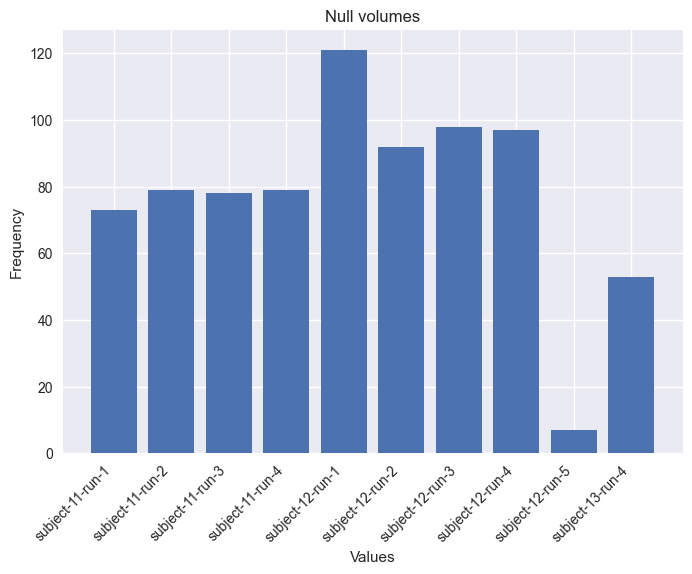

In [55]:
import matplotlib.pyplot as plt

nonzero = {}

for label, values in fucked.items():
    if values['fucked'] != 0:
        s = label.split("-")
        nonzero[f"subject-{s[0]}-run-{s[1]}"] = values['fucked']

plt.bar(nonzero.keys(), nonzero.values())
plt.xticks(
    ticks=range(len(nonzero)),
    labels=nonzero.keys(),
    rotation=45,       # Rotate labels if needed
    ha='right'         # Align labels to the right
)

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Null volumes')
plt.legend()

In [9]:
from nilearn.input_data import NiftiMasker
import numpy as np

fucked_voxels = {}

for sub in subjects:
    print(sub)
    for run in runs:

        try:
            m = MRI(sub, run, folder='..')
            dat = m.data
            mask = NiftiMasker(mask_img=m.brain_mask)
            mask.fit()
            voxels = mask.transform(dat)

            fucked_voxels[f"{sub}-{run}"] = {
                "fucked": np.count_nonzero(voxels == 0),
                "total": voxels.shape[1]
            }
        except Exception as e:
            print(e)
            continue


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
Compressed file ended before the end-of-stream marker was reached
23
24
25
26
27
28
29
30
31
32
33


In [59]:
m = MRI(1, 1, folder='..')
dat = m.data
mask = NiftiMasker(mask_img=m.brain_mask,)
mask.fit()
voxels = mask.fit_transform(dat)


C:\Users\ducat\AppData\Local\Temp\ipykernel_10920\4256567259.py:5: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  voxels = mask.fit_transform(dat)


In [60]:
np.count_nonzero(voxels == 0)

11916456

In [61]:
(np.nanmin(voxels), np.nanmax(voxels))

(np.float64(0.0), np.float64(0.0))

In [62]:
fdat = dat.get_fdata()

In [63]:
np.count_nonzero(fdat == 0)

46035864

In [64]:
(np.nanmin(fdat), np.nanmax(fdat))

(np.float64(-7.312333583831787), np.float64(6.0894083976745605))

D:\github\scz_familiarity_fMRI_ML\scratches\..\stats.py:232: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  voxels = masker.fit_transform(fmri_img)  # shape: (timepoints, voxels)
D:\github\scz_familiarity_fMRI_ML\scratches\..\stats.py:232: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  voxels = masker.fit_transform(fmri_img)  # shape: (timepoints, voxels)
D:\github\scz_familiarity_fMRI_ML\scratches\..\stats.py:282: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


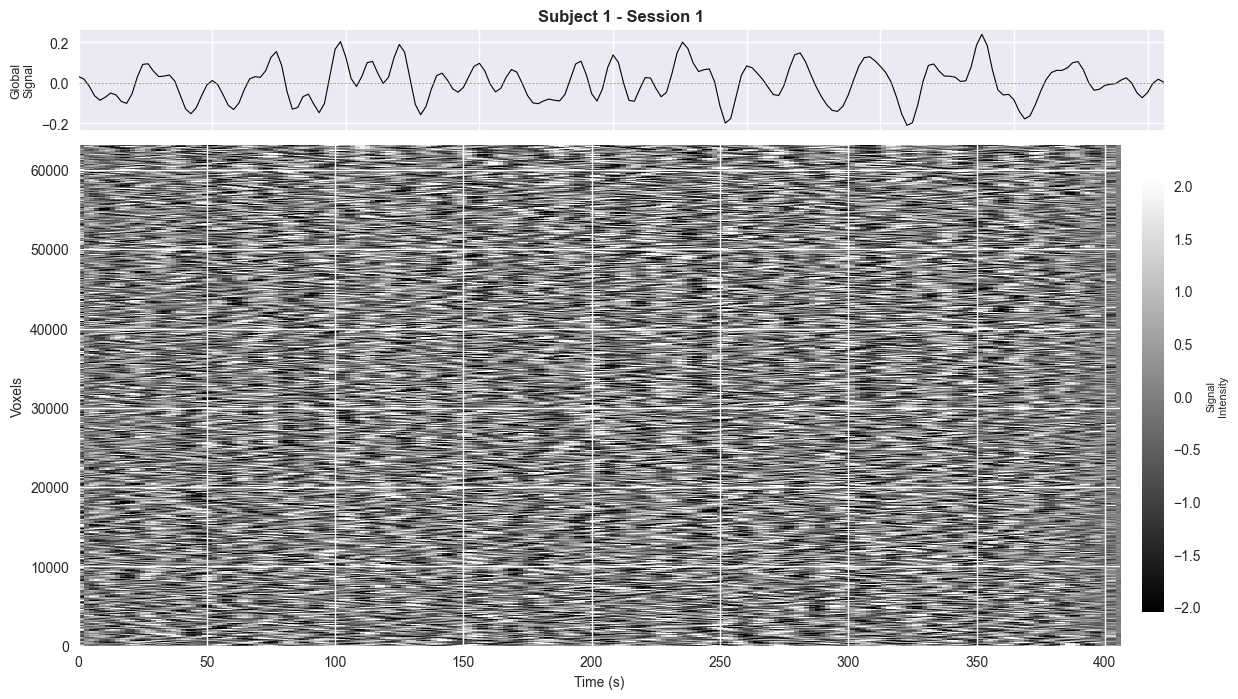

In [2]:
from stats import carpet_plot

m      = MRI(7, 4, folder='..')
fig    = carpet_plot(
    fmri_img  = m.data,
    mask_img  = m.brain_mask,
    t_r       = 2.0,
    standardize = True,
    title     = "Subject 1 - Session 1"
)


In [33]:
# Check if the raw data itself contains non-zero values
print("Data shape:", dat.shape)
print("Data min/max:", np.nanmin(dat.get_fdata()), np.nanmax(dat.get_fdata()))
print("Non-zero voxels in raw data:", np.count_nonzero(dat.get_fdata()))


Data shape: (65, 77, 55, 204)
Data min/max: -7.312333583831787 6.0894083976745605
Non-zero voxels in raw data: 10120236


In [34]:
# Verify the mask is valid and overlaps with your data
mask_data = m.brain_mask.get_fdata()
print("Mask shape:", mask_data.shape)
print("Mask unique values:", np.unique(mask_data))
print("Non-zero voxels in mask:", np.count_nonzero(mask_data))

# Check if mask and data are in the same space
print("\nData affine:\n", dat.affine)
print("\nMask affine:\n", m.brain_mask.affine)


Mask shape: (65, 77, 55)
Mask unique values: [0. 1.]
Non-zero voxels in mask: 58414

Data affine:
 [[   3.           0.           0.         -96.5      ]
 [   0.           3.           0.        -132.5      ]
 [   0.           0.           3.5999999  -78.5      ]
 [   0.           0.           0.           1.       ]]

Mask affine:
 [[   3.           0.           0.         -96.5      ]
 [   0.           3.           0.        -132.5      ]
 [   0.           0.           3.5999999  -78.5      ]
 [   0.           0.           0.           1.       ]]


In [27]:
voxels.shape

(204, 58414)

In [22]:
np.where(dat.get_fdata() != 0)

(array([ 0,  0,  0, ..., 64, 64, 64], shape=(10120236,)),
 array([ 0,  0,  0, ..., 76, 76, 76], shape=(10120236,)),
 array([ 0,  0,  0, ..., 50, 50, 50], shape=(10120236,)),
 array([  0,   1,   2, ..., 201, 202, 203], shape=(10120236,)))

In [14]:
for label, values in fucked_voxels.items():
    if values['fucked'] < 10000:
        print(values['fucked'])


204
612
816
612
2958
1428
1224
0
0
1122
1836
1632
4896
1836
1836
5712
1632
1836
4488
1020
591
1200
4200
1400
1836
2040
1632
3060
816
408
7140
4896
5712
2958
2448
0
2040
0
0
0
1428
1836
1428
408
6120
612
1428
1224
612
0
0
0
0
714
0
0
0
0
0
7344
1224
1224
1
918
612
816
1021
1020
2856
2244
3876
3672
2856
2856
6936
6324
5304
612
918
0
204
0
408
612
612
612
204
204
1020
3672
2040
7344
3468
4692
1224
1632
1224
2040
918
1428
204
2448
1632
1734
4080
5508
4896
4386
612
1
0
0
0
2244
1632
204
408
204
4488
6732
6325
7548
4488
2448
4284
2448
2040
0
0
204
0
0
0
0
0
0
306
1632
204
204
1020
0
0
1
0
204
204
1020
408
613
0
612
2448
2040
3672
0
510
2040
408
5712
1836
9588


C:\Users\ducat\AppData\Local\Temp\ipykernel_21316\3262418940.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


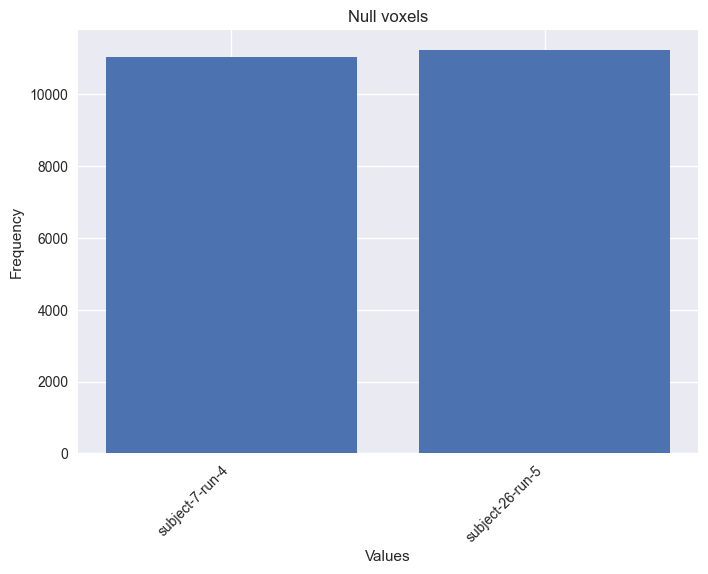

In [15]:
import matplotlib.pyplot as plt

nonzero = {}

for label, values in fucked_voxels.items():
    if values['fucked'] > 10000:
        s = label.split("-")
        nonzero[f"subject-{s[0]}-run-{s[1]}"] = values['fucked']

plt.bar(nonzero.keys(), nonzero.values())
plt.xticks(
    ticks=range(len(nonzero)),
    labels=nonzero.keys(),
    rotation=45,       # Rotate labels if needed
    ha='right'         # Align labels to the right
)

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Null voxels')
plt.legend()